# Matplotlib


Pyplot ist das *stateful interface* zu matplotlib.
This notebook is the practical entry point into Matplotlib (mlp), but with a stronger conceptual bridge between the examples.

It combines the quick-start feel of this video notebook with selected ideas from `Kopie_von_Intro_to_matplotlib.ipynb` (werden wir hin wechseln nach Chapter 0) and `matplotlib_fundamentals_explained.ipynb` (linspace).

**What you will learn**

1. The two main ways of creating plots: `pyplot` and the object-oriented (OO) interface
2. How to go from an empty `plt.plot()` call to plotting real x/y data
3. Why `fig, ax = plt.subplots()` is the default pattern we keep coming back to; ax "axes" heißt, fig für "figure" steht
4. How `np.linspace()` helps create smooth lines and well-spaced axes
4.1 The most common plot types with NumPy arrays and pandas data
5. How to customize labels, legends, ticks, limits, styles, and colors
6. How to save plots and where to go next afterwards

A short roadmap to the follow-up notebooks is included at the end.

In [19]:
import matplotlib as mlp
import matplotlib.pyplot as plt #API interface , pyplot

import numpy as np
import pandas as pd

**Characteristics**

Matplotlib is an excellent 2D and 3D graphics library for generating scientific figures. Some of the many advantages of this library include:

* Easy to get started
* Support for $\LaTeX$ formatted labels and texts
* Great control of every element in a figure, including figure size and DPI.
* High-quality output in many formats, including PNG, PDF, SVG, EPS, and PGF.
* GUI for interactively exploring figures *and* support for headless generation of figure files (useful for batch jobs).

One of the key features of matplotlib that I would like to emphasize, and that I think makes matplotlib highly suitable for generating figures for scientific publications is that all aspects of the figure can be controlled *programmatically*. This is important for reproducibility and convenient when one needs to regenerate the figure with updated data or change its appearance.

More information at the Matplotlib web page: http://matplotlib.org/



Since we are in a Jupyter notebook, we also execute the following statement to output plots directly in the Jupyter notebook:

We also load the Python numerical library (NumPy: Numerical Python) and Pandas with their import convention:

In [20]:
import matplotlib as mpl
mpl.rcParams['axes.xmargin']   # default 0.05
mpl.rcParams['axes.ymargin']   # default 0.05

0.05

In [21]:
#For add_axes — it's relative to the figure, so:For add_axes — it's relative to the figure, so:
mpl.rcParams['figure.figsize']      # (6.4, 4.8) default width/height in inches
mpl.rcParams['figure.dpi']          # 100 — so 640x480 pixels default

#that's what the [left, bottom, width, height] coords are relative to — the figure canvas in 0-1 figure coordinates.

#For add_subplot — it's about the grid spacing:
mpl.rcParams['figure.subplot.left']    # 0.125 — left edge of subplots
mpl.rcParams['figure.subplot.right']   # 0.9   — right edge
mpl.rcParams['figure.subplot.bottom']  # 0.11  — bottom edge
mpl.rcParams['figure.subplot.top']     # 0.88  — top edge
mpl.rcParams['figure.subplot.wspace']  # 0.2   — width space between subplots
mpl.rcParams['figure.subplot.hspace']  # 0.2   — height space between subplots
#these are what matplotlib uses to auto-position subplots within the figure — the numbers add_axes makes you define manually.

0.2

## Class/object related notes


**What you will learn**

1. The two main ways of creating plots: `pyplot` and the object-oriented (OO) interface
2. How to go from an empty `plt.plot()` call to plotting real x/y data
3. Why `fig, ax = plt.subplots()` is the default pattern we keep coming back to; ax "axes" heißt, fig für "figure" steht
4. How `np.linspace()` helps create smooth lines and well-spaced axes
4.1 The most common plot types with NumPy arrays and pandas data
5. How to customize labels, legends, ticks, limits, styles, and colors
6. How to save plots and where to go next afterwards

A short roadmap to the follow-up notebooks is included at the end.

### pyplot & OO

Matplotlib gives us two closely related interfaces:

- `pyplot`: quick, state-based, great for getting started fast
- `OO` (object-oriented): explicit and more robust, especially when plots become more complex

We will start with `pyplot` because it makes the first examples very easy to read. Then we will switch to `fig, ax = plt.subplots()` in (## Object-oriented ) and use that pattern as our default.

Start by importing `matplotlib.pyplot` and enabling inline output in the notebook.


Without a semicolon, Jupyter prints the Python return value of `plt.plot()`, which is usually a list of `Line2D` objects.

A trailing `;` suppresses that text output. It does **not** change the figure itself, it only keeps the notebook output cleaner.


In [110]:
# You could use plt.show() if you want, zeigt eine figur als .png
#plt.plot()
plt.show()

In [111]:
#fig = plt.figure()  # explicitly creates a figure
plt.show()          # shows it (empty, since nothing was plotted)

In [27]:
#Every object in Python has __repr__ yes — it's defined on the base object class that everything inherits from.

#there are two:
#__repr__    # unambiguous, for developers — shown in REPL/Jupyter
#__str__     # readable, for users — used by print()
#print() calls __str__ first, falls back to __repr__ if __str__ isn't defined.
#Jupyter just calls __repr__ directly when you evaluate an expression in a cell.

In [28]:
#plt.gcf() #getCurrentFigure()

#It prints because Figure has a __repr__ method defined — that's the Python special method that controls what an object looks like when printed/displayed.
#Specifically:
#fig.__repr__()
#plt.gcf() #getCurrentFigure()

print(fig.get_size_inches())          # [6.4, 4.8]
print(fig.dpi)                        # 100
#print(fig.get_size_inches()) * fig.dpi  # [640, 480]
print(len(fig.axes))                  # 0

# returns: '<Figure size 640x480 with 0 Axes>'

[6.4 4.8]
100.0
1


In [29]:
#and this is true for all Artists — they all have __repr__ defined:
ax.__repr__()      # <Axes: >
#line.__repr__()    # <matplotlib.lines.Line2D object at

'<Axes: >'

## Relation in Matplotlib

A potentially confusing feature of Matplotlib is that it has two coding interfaces:

* Matlab-like syntax (state-based)
* Object-oriented (OO) syntax (more powerful).

This is partly the reason why matplotlib doesn't have one consistent way of achieving the same given output, making it a bit difficult to understand for newcomers.

So far we have seen both interfaces in action, with a bit more focus on the OO syntax, which is more intuitive and pythonic to work with.

However, since the original purpose of matplotlib was to recreate the plotting facilities of Matlab in Python, the Matlab-like syntax is retained and still works.

The Matlab syntax is state-based, or "stateful".
That means that `plt` keeps track of what the current axes is. So whatever you draw with `plt.{anything}` will be reflected only on the **current** subplot.

In practice, the main difference between the two interfaces is:

* Matlab - all plotting is done using `plt` methods
* OO - all plotting is done using the respective axes methods.

So, the general procedure for the Matlab interface is:

* You manually create one subplot at a time (using `plt.subplot()` or `plt.add_subplot()`) and
* immediately call `plt.plot()` or `plt.{anything}` to modify that specific subplot (axes).

Whatever method you call using `plt` will be drawn in the current axes.

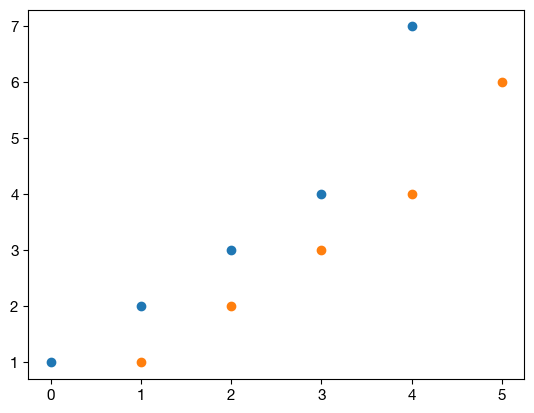

In [ ]:
# Let's add some data
y=[1,2,3,4,7]
#impliziert: 
# x=[0,1,2,3,4]
plt.plot(y, 'o')

#f(x)=x Definitionsbereich von 1-5
#indizes in Python beginnen mit 0 (meistens), und die gehen bis len(y)-1
#plt.show()

# Create some data
x: list[int] = [1, 2, 3, 4, 5] #0 ... len(y)-1
y: list[int]=[1,2,3,4,6] 
#genau das selbe

# With a semi-colon and now a y value
plt.plot(x, y, 'o');
#plt.show()

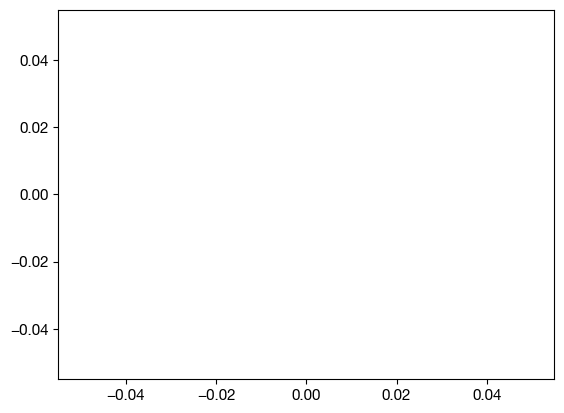

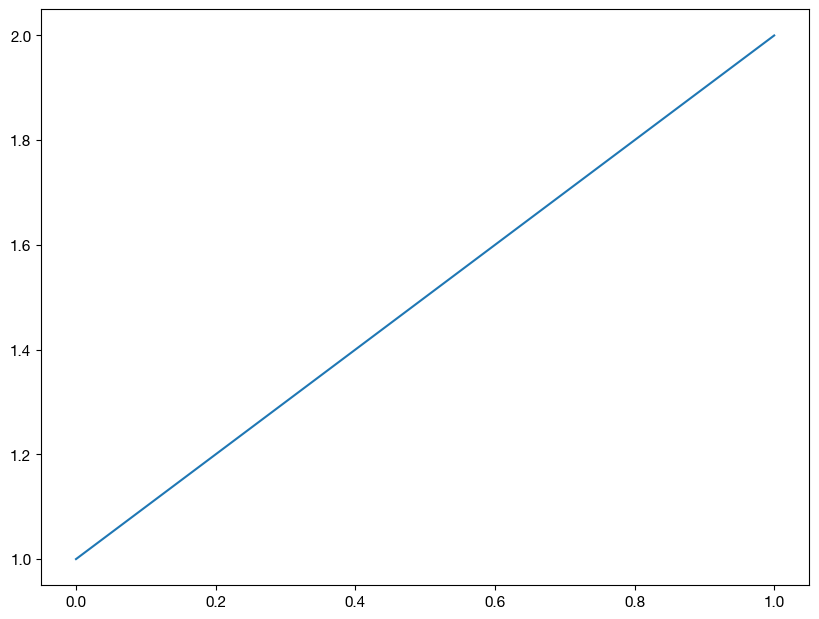

In [116]:
#plt.show()   # nothing to show yet — no figure exists, this is essentially a no-op
plt.plot()   # creates an implicit figure, draws on it

# Jupyter notebooks automatically display matplotlib figures as output
# This happens even WITHOUT %matplotlib inline (which is commented out above)
# The figure is shown because Jupyter displays the last expression's result
# In a regular Python script, you would need plt.show() to display the plot

#check and create a .py with just; import matplotlib.pyplot as plt 
#                                 plt.plot() #see what happens (answer: nothing)

# Create a simple plot, without the semi-colon
#plt.plot()        # draws → needs axes → needs figure → creates both as objects

fig = plt.figure()
ax = fig.add_axes([0.1, 0.1, 1.2, 1.2])  # [left, bottom, width, height] in figure coordinates
#left, bottom (relative/prozent zu einem bestimmten Punkt ; Prozent zum "default Größe")
# Unterschied ist das du hierbei die volle Kontrolle hast wie du es platzierst

#comment each out and try out
plt.plot([1,2])
#plt.show()
#plt.gcf()

### Details über Artists

**Advanced** To get back to later

Figure   1 ── * Axes
Axes     1 ── * Line2D
Axes     1 ── * Patch
Axes     1 ── * Text
Axes     1 ── * Collection

**Navigation — Kind kennt Elternteil**

```python
fig.axes           # Figure  → alle Axes      [ax1, ax2, ...]
ax.get_figure()    # Axes    → Figure

ax.lines           # Axes    → alle Line2D    [line1, ...]
ax.patches         # Axes    → alle Patches   [rect1, ...]
ax.texts           # Axes    → alle Texts     [txt1, ...]
ax.collections     # Axes    → alle Collections (scatter...)

line.axes          # Line2D  → Axes
line.axes.figure   # Line2D  → Figure (über Axes)
```

**Regel**

> jedes Artist-Kind kennt seinen Elternteil  
> kein Artist kann ohne Elternteil existieren — Axes braucht Figure, Line2D braucht Axes

Let's understand figure and axes in little more detail.

Suppose I want to draw our two sets of points (green rounds and blue stars) in two separate plots side-by-side instead of the same plot.

You can do that by creating two separate subplots, or Axes, using `plt.subplots(1, 2)`: this means to creates 1 row with 2 subplots. The command returns two objects:

1. the figure
1. the axes (subplots) inside the figure

![](https://www.machinelearningplus.com/wp-content/uploads/2019/01/99_matplotlib_structure-1.png)

Previously, I called `plt.plot()` to draw the points. Since there was only one axes by default, it drew the points on that axes itself.

But now, since you want the points drawn on different subplots (axes), you have to call the plot function **on the respective axes**.

Anzahl Figure-Patches: 2
Patch-Typen: ['Rectangle', 'Circle']


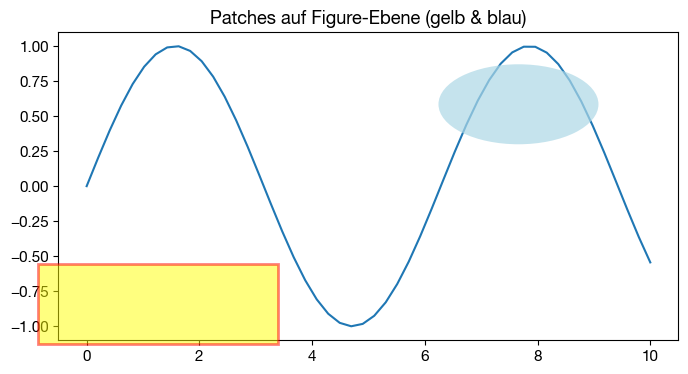

In [103]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# Beispieldaten
x = np.linspace(0, 10, 50)
y = np.sin(x)
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(x, y)

# Patches DIREKT auf Figure (nicht auf Axes!)
# Diese sind über ALLEN Subplots
rect = mpatches.Rectangle((0.1, 0.1), 0.3, 0.2, 
                          transform=fig.transFigure,  # Figure-Koordinaten!
                          facecolor='yellow', alpha=0.5, 
                          edgecolor='red', linewidth=2)
circle = mpatches.Circle((0.7, 0.7), 0.1, 
                         transform=fig.transFigure,
                         facecolor='lightblue', alpha=0.7)

fig.patches.append(rect)
fig.patches.append(circle)

ax.set_title('Patches auf Figure-Ebene (gelb & blau)')
print(f"Anzahl Figure-Patches: {len(fig.patches)}")
print(f"Patch-Typen: {[type(p).__name__ for p in fig.patches]}")

plt.show()


Anzahl Figure-Lines: 1
Anzahl Axes-Lines in ax1: 1
Anzahl Axes-Lines in ax2: 1


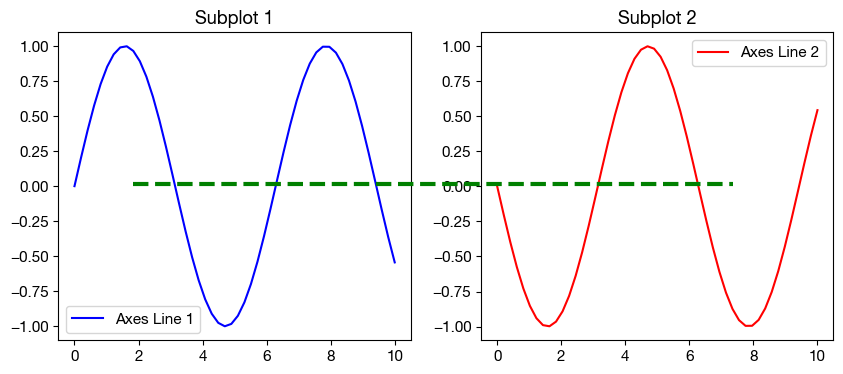

In [104]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

x = np.linspace(0, 10, 50)
y = np.sin(x)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

# Normale Axes-Lines
ax1.plot(x, y, 'b-', label='Axes Line 1')
ax2.plot(x, -y, 'r-', label='Axes Line 2')

# Line DIREKT auf Figure
fig_line = Line2D([0.2, 0.8], [0.5, 0.5],
                  transform=fig.transFigure,
                  color='green', linewidth=3, 
                  linestyle='--', label='Figure Line')
fig.lines.append(fig_line)

ax1.legend()
ax2.legend()
ax1.set_title('Subplot 1')
ax2.set_title('Subplot 2')

print(f"Anzahl Figure-Lines: {len(fig.lines)}")
print(f"Anzahl Axes-Lines in ax1: {len(ax1.lines)}")
print(f"Anzahl Axes-Lines in ax2: {len(ax2.lines)}")

plt.show()
